In [1]:
from generic_business_case_runner import run_business_case
from NSE6_EL_input_data import el_parameters
import ipynb.fs.defs.EL_working_file as el_module


Active Scenario: most_likely (Index: 1)
All variables saved to NSE_get_data_from_ESDL.pkl


In [2]:
run_business_case(el_module,el_parameters)

TypeError: taxes_and_profits_part2() missing 2 required positional arguments: 'df_taxes_and_profits_part1' and 'df_debt_and_loan_part1'

In [9]:
import copy
import pandas as pd
import numpy as np

def run_oat_sensitivity(working_module, runner_module, base_parameters):
    """
    Runs a One-At-A-Time sensitivity analysis over all parameters in our dictionary.
    Calcualtes the impact of -10% en +10% on the chosen KPI's.
    """
    # We don't need to do the sensitivity over the general business case data
    excluded_keys = [
        "duration_construction", 
        "duration_operation", 
        "duration_decommissioning", 
        "tender_year",
        "depreciation",
        "annuity_loan",
        "construction_years_list",
        "contingency_percentage"
    ]

    sensitivity_results = []

    for key, original_value in base_parameters.items():

        if key in excluded_keys:
            continue

        row_data = {"Variable": key}

        # Calculate scenarios: -10% and +10%
        scenarios = (
            ("Minus_10", 0.9), 
            ("Plus_10", 1.1),
        )

        for factor_name, factor in scenarios:
            
            # 1. Create a clean deep copy of the base parameters
            scen_params = copy.deepcopy(base_parameters)
            
            # 2. Apply multiplication (works automatically for both numbers and DataFrames!)
            scen_params[key] = original_value * factor
            
            # 3. Run the business case using the runner
            project_kpi_df, equity_kpi_df, output_kpi_df = runner_module.run_business_case(working_module, scen_params)
                
            # 4. Extract results (ensure row labels match your exact output tables)
            row_data[f"Project_NPV_{factor_name}"] = project_kpi_df.loc['net_present_value'].iloc[0]
            row_data[f"Equity_NPV_{factor_name}"]  = equity_kpi_df.loc['net_present_value'].iloc[0]
            row_data[f"LCOH_{factor_name}"]        = output_kpi_df.loc['levelized_cost'].iloc[0]
            row_data[f"Gap_{factor_name}"]         = output_kpi_df.loc['levelized_profits'].iloc[0]
                
        sensitivity_results.append(row_data)

    # Convert collected data into the 4 dataframes
    df_sens = pd.DataFrame(sensitivity_results)

    # Helper function to clean up the dfs, set the index
    def finalize_table(df, value_cols):
        # Select target columns, rename them, and set 'Variable' as the clean index
        table = df[["Variable"] + value_cols].copy()
        table.rename(columns={value_cols[0]: "-10%", value_cols[1]: "+10%"}, inplace=True)
        table.set_index("Variable", inplace=True)

        # Return values into numeric floats for future use
        return table.apply(pd.to_numeric, errors='coerce')
    
    table_project_npv = finalize_table(df_sens, ["Project_NPV_Minus_10", "Project_NPV_Plus_10"])
    table_equity_npv  = finalize_table(df_sens, ["Equity_NPV_Minus_10", "Equity_NPV_Plus_10"])
    table_lco         = finalize_table(df_sens, ["LCOH_Minus_10", "LCOH_Plus_10"])
    table_gap         = finalize_table(df_sens, ["Gap_Minus_10", "Gap_Plus_10"])
    
    return table_project_npv, table_equity_npv, table_lco, table_gap

In [10]:
import generic_business_case_runner as runner
import ipynb.fs.defs.EL_working_file as el_module
from NSE6_EL_input_data import el_parameters

# Important: Make sure your run_business_case function in the runner 
# returns the 4 KPI dataframes at the very end!
df_proj_npv, df_eq_npv, df_lco, df_gap = run_oat_sensitivity(el_module, runner, el_parameters)

# View all tables
print("--- 1) PROJECT NPV SENSITIVITY ---")
display(df_proj_npv.style.format(precision=2))

print("\n--- 2) EQUITY NPV SENSITIVITY ---")
display(df_eq_npv.style.format(precision=2))

print("\n--- 3) LEVELIZED COST SENSITIVITY ---")
display(df_lco.style.format(precision=2))

print("\n--- 4) UNPROFITABLE GAP SENSITIVITY ---")
display(df_gap.style.format(precision=2))

--- 1) PROJECT NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-1177.05,-1132.82
wacc,-1155.90,-1209.43
income_tax_rate,-1186.18,-1186.18
inflation,-1198.65,-1173.36
loan_interest_rate,-1186.18,-1186.18
loan_percentage,-1186.18,-1186.18
decommissioning_percentage,-1185.67,-1186.70
capex,-1010.96,-1361.40
opex_df,-1068.78,-1303.58



--- 2) EQUITY NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-1167.28,-1142.02
wacc,-1197.80,-1166.75
income_tax_rate,-1175.35,-1190.36
inflation,-1189.84,-1175.70
loan_interest_rate,-1173.22,-1193.02
loan_percentage,-1233.13,-1128.23
decommissioning_percentage,-1182.34,-1183.37
capex,-1048.87,-1315.30
opex_df,-1085.47,-1284.46



--- 3) LEVELIZED COST SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,393.86,388.26
wacc,381.27,405.49
income_tax_rate,392.54,393.68
inflation,387.43,398.95
loan_interest_rate,391.21,395.20
loan_percentage,390.54,395.99
decommissioning_percentage,393.07,393.15
capex,376.49,410.25
opex_df,385.68,400.86



--- 4) UNPROFITABLE GAP SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-129.42,-121.19
wacc,-114.72,-141.05
income_tax_rate,-127.06,-128.21
inflation,-128.17,-127.09
loan_interest_rate,-125.73,-129.73
loan_percentage,-125.06,-130.51
decommissioning_percentage,-127.59,-127.67
capex,-111.01,-144.78
opex_df,-120.21,-135.38


In [ ]:
kflskje


**Sensitivity analysis**

In [1]:
import copy
import pandas as pd
import numpy as np

def run_oat_sensitivity(working_module, runner_module, base_parameters):
    """
    Runs a One-At-A-Time sensitivity analysis over all parameters in our dictionary.
    Calcualtes the impact of -10% en +10% on the chosen KPI's.
    """
    # We don't need to do the sensitivity over the general business case data
    excluded_keys = [
        "duration_construction", 
        "duration_operation", 
        "duration_decommissioning", 
        "tender_year",
    ]

    sensitivity_results = []

    for key, original_value in base_parameters.items():

        if key in excluded_keys:
            continue

        row_data = {"Variable": key}

        # Calculate scenarios: -10% and +10%
        scenarios = (
            ("Minus_10", 0.9), 
            ("Plus_10", 1.1),
        )

        for factor_name, factor in scenarios:
            
            # 1. Create a clean deep copy of the base parameters
            scen_params = copy.deepcopy(base_parameters)
            
            # 2. Apply multiplication (works automatically for both numbers and DataFrames!)
            scen_params[key] = original_value * factor
            
            # 3. Run the business case using the runner
            project_kpi_df, equity_kpi_df, output_kpi_df = runner_module.run_business_case(working_module, scen_params)
                
            # 4. Extract results (ensure row labels match your exact output tables)
            row_data[f"Project_NPV_{factor_name}"] = project_kpi_df.loc['net_present_value'].iloc[0]
            row_data[f"Equity_NPV_{factor_name}"]  = equity_kpi_df.loc['net_present_value'].iloc[0]
            row_data[f"LCOH_{factor_name}"]        = output_kpi_df.loc['levelized_cost'].iloc[0]
            row_data[f"Gap_{factor_name}"]         = output_kpi_df.loc['levelized_profits'].iloc[0]
                
        sensitivity_results.append(row_data)

    # Convert collected data into the 4 dataframes
    df_sens = pd.DataFrame(sensitivity_results)

    # Helper function to clean up the dfs, set the index
    def finalize_table(df, value_cols):
        # Select target columns, rename them, and set 'Variable' as the clean index
        table = df[["Variable"] + value_cols].copy()
        table.rename(columns={value_cols[0]: "-10%", value_cols[1]: "+10%"}, inplace=True)
        table.set_index("Variable", inplace=True)

        # Return values into numeric floats for future use
        return table.apply(pd.to_numeric, errors='coerce')
    
    table_project_npv = finalize_table(df_sens, ["Project_NPV_Minus_10", "Project_NPV_Plus_10"])
    table_equity_npv  = finalize_table(df_sens, ["Equity_NPV_Minus_10", "Equity_NPV_Plus_10"])
    table_lco         = finalize_table(df_sens, ["LCOH_Minus_10", "LCOH_Plus_10"])
    table_gap         = finalize_table(df_sens, ["Gap_Minus_10", "Gap_Plus_10"])
    
    return table_project_npv, table_equity_npv, table_lco, table_gap

In [2]:
import generic_business_case_runner as runner
import ipynb.fs.defs.EL_working_file as el_module
from NSE6_EL_input_data import el_parameters

# Important: Make sure your run_business_case function in the runner 
# returns the 4 KPI dataframes at the very end!
df_proj_npv, df_eq_npv, df_lco, df_gap = run_oat_sensitivity(el_module, runner, el_parameters)

# View all tables
print("--- 1) PROJECT NPV SENSITIVITY ---")
display(df_proj_npv.style.format(precision=2))

print("\n--- 2) EQUITY NPV SENSITIVITY ---")
display(df_eq_npv.style.format(precision=2))

print("\n--- 3) LEVELIZED COST SENSITIVITY ---")
display(df_lco.style.format(precision=2))

print("\n--- 4) UNPROFITABLE GAP SENSITIVITY ---")
display(df_gap.style.format(precision=2))

Active Scenario: most_likely (Index: 1)
All variables saved to NSE_get_data_from_ESDL.pkl
--- 1) PROJECT NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-1177.05,-1132.82
wacc,-1155.90,-1209.43
income_tax_rate,-1186.18,-1186.18
inflation,-1198.65,-1173.36
loan_interest_rate,-1186.18,-1186.18
loan_percentage,-1186.18,-1186.18
decommissioning_percentage,-1185.67,-1186.70
capex,-1010.96,-1361.40
opex_df,-1068.78,-1303.58



--- 2) EQUITY NPV SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-1167.28,-1142.02
wacc,-1197.80,-1166.75
income_tax_rate,-1182.85,-1182.85
inflation,-1189.84,-1175.70
loan_interest_rate,-1173.22,-1193.02
loan_percentage,-1233.13,-1128.23
decommissioning_percentage,-1182.34,-1183.37
capex,-1048.87,-1315.30
opex_df,-1085.47,-1284.46



--- 3) LEVELIZED COST SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,393.86,388.26
wacc,381.27,405.49
income_tax_rate,393.11,393.11
inflation,387.43,398.95
loan_interest_rate,391.21,395.20
loan_percentage,390.54,395.99
decommissioning_percentage,393.07,393.15
capex,376.49,410.25
opex_df,385.68,400.86



--- 4) UNPROFITABLE GAP SENSITIVITY ---


,-10%,+10%
Variable,,
lifetime_investment,-129.42,-121.19
wacc,-114.72,-141.05
income_tax_rate,-127.63,-127.63
inflation,-128.17,-127.09
loan_interest_rate,-125.73,-129.73
loan_percentage,-125.06,-130.51
decommissioning_percentage,-127.59,-127.67
capex,-111.01,-144.78
opex_df,-120.21,-135.38


# CHECK income tax rate sensitivity!

Tornado graphs

In [3]:
from ipynb.fs.defs.EL_working_file import project_kpi, equity_kpi, output_kpi

def get_base_case_values(working_module, parameters):
    """
    Extracts baseline KPIs from any business case module
    """
    
    # Run the functions from the business case module to get the desired dfs
    project_df = working_module.project_kpi(**parameters)
    equity_df = working_module.equity_kpi(**parameters)
    output_df = working_module.output_kpi(**parameters)

    # Get the numbers from the dfs
    return {
        'Project NPV':       project_df.loc['net_present_value'].iloc[0],
        'Equity NPV':        equity_df.loc['net_present_value'].iloc[0],
        'Levelized Cost':    output_df.loc['levelized_cost'].iloc[0],
        'Unprofitable Gap':  output_df.loc['levelized_profits'].iloc[0]
    }

In [4]:
import matplotlib.pyplot as plt

def tornado_plot(df_sa, base_case, sa_type):

    # Create percentage change from the NPV values
    df_sensitivity_analysis_percentage = -(df_sa - base_case)/base_case*100

    # Sort the values. Here we use ascending=True because the default behavior of matplotlib's barh() function (which creates horizontal bar charts) 
    # is to plot the first entry at the bottom and the last entry at the top.
    df_sensitivity_analysis_percentage.sort_values(by='-10%', key=abs, ascending=True, inplace=True)

    # Data for the tornado plot
    variables = df_sensitivity_analysis_percentage.index.tolist()

    negative_changes = df_sensitivity_analysis_percentage['-10%'].tolist()
    positive_changes = df_sensitivity_analysis_percentage['+10%'].tolist()

    # Create the tornado plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Define bar positions
    y_pos = np.arange(len(variables))

    # Create horizontal bars
    ax.barh(y_pos, negative_changes, align='center', color='red', label='-10%')
    ax.barh(y_pos, positive_changes, align='center', color='blue', label='+10%')

    # Add a vertical line at the base value (0)
    ax.axvline(x=0, color='black', linestyle='--')

    # Remove underscore from variables for the figure names
    cleaned_variables = [var.replace("_", " ")
                        .replace("variable", "")
                        .replace("df", "")
                        .strip()
                        .capitalize()
                        .replace("Capex", "CAPEX")
                        .replace("Opex", "OPEX")
                        .replace("Hwi", "HWI")
                        .replace("Wacc", "WACC") for var in variables]

    # Set y-axis labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(cleaned_variables)

    # Add labels and title
    ax.set_xlabel(f'Change in {sa_type} (%)')
    ax.set_title('Sensitivity Analysis')

    # Add grey horizontal grid lines
    ax.grid(True, axis='y', color='grey', linestyle='-', linewidth=0.5, alpha=0.3)

    # Show legend
    ax.legend()

    # Display the plot
    plt.tight_layout()
    plt.show()


        

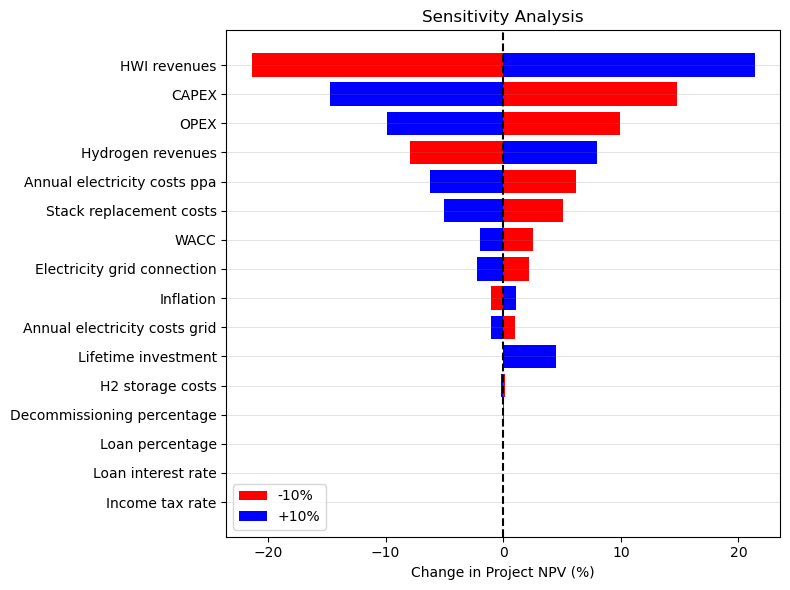

In [5]:
import ipynb.fs.defs.EL_working_file as el_module
from NSE6_EL_input_data import el_parameters

# To run for electrolyser, we first get the base case values
el_base_cases = get_base_case_values(el_module, el_parameters)

# Plot the Project NPV tornado graph 
tornado_plot(df_proj_npv,el_base_cases['Project NPV'],'Project NPV')

# Plot the Equity NPV tornado graph 
# tornado_plot(df_eq_npv,el_base_cases['Equity NPV'], 'Equity NPV')

# Plot the Levelized Cost tornado graph
# tornado_plot(df_lco, el_base_cases['Levelized Cost'], 'Levelized Cost')

# Plot the Unprofitable Gap tornado graph
# tornado_plot(df_gap,el_base_cases['Unprofitable Gap'], 'Unprofitable Gap')

Cumulative equity and debt figure

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_cumulative_cashflows(working_module, runner_module, parameters):
    """
    Executes a business case scenario and generates a cumulative equity and debt figure
    """

    # Run the business case 
    runner_module.run_business_case(working_module,parameters)

    # Extract the timeline years from the module
    years = working_module.construct_calendar_year_list(**parameters)

    # Get the cumulative equity and debt cashflows
    df_cumulative_equity_debt = working_module.cumulative_equity_and_debt_cashflows(**parameters)

    # Extract rows to lists
    cumulative_equity_cashflow = df_cumulative_equity_debt.loc['cumulative_equity_cashflow'].tolist()
    cumulative_debt_cashflow = df_cumulative_equity_debt.loc['cumulative_debt_cashflow'].tolist()

    # Plot

    # Set the width of each bar
    bar_width = 0.35

    # Set the position of the bars on the x-axis
    r1 = np.arange(len(years))
    r2 = [x + bar_width for x in r1]

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 6))

    # Create bars for cumulative equity cashflow
    ax.bar(r1, cumulative_equity_cashflow, color='blue', width=bar_width, label='Equity Cashflow')

    # Create bars for cumulative debt cashflow
    ax.bar(r2, cumulative_debt_cashflow, color='red', width=bar_width, label='Debt Cashflow')

    # Add a horizontal line at y=0
    ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

    # Add labels and title
    ax.set_xlabel('Year')
    ax.set_ylabel('Cumulative Cashflow (MEUR)')
    ax.set_title('Cumulative Equity and Debt Cashflows')

    # Add xticks on the middle of the group bars
    ax.set_xticks([r + bar_width/2 for r in range(len(years))])
    ax.set_xticklabels(years, rotation=45)

    # Add legend
    ax.legend()

    # Display the plot
    plt.tight_layout()
    plt.show()


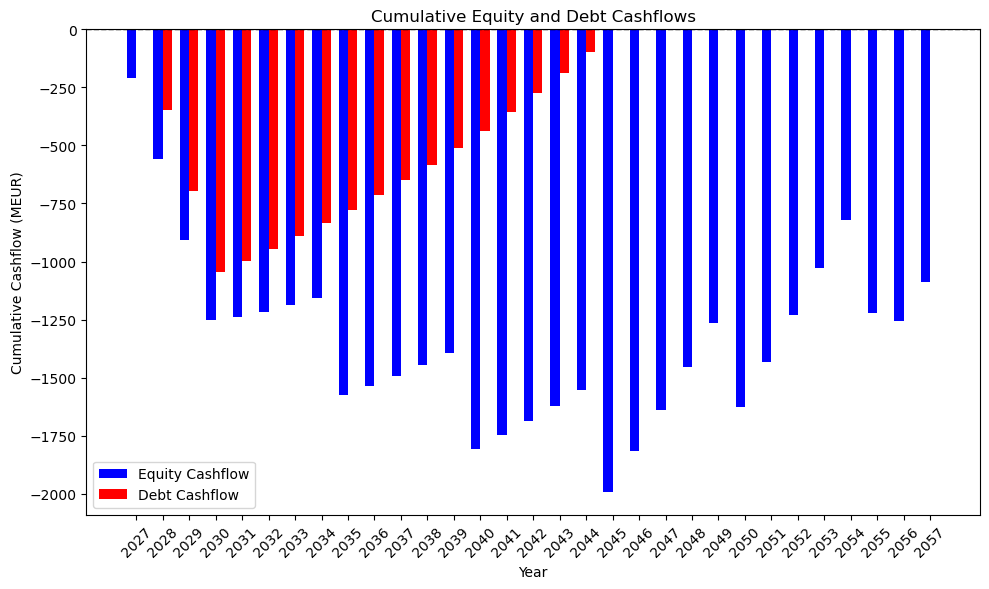

In [7]:
import generic_business_case_runner as runner
import ipynb.fs.defs.EL_working_file as el_module
from NSE6_EL_input_data import el_parameters

# Plot the graph cleanly
plot_cumulative_cashflows(el_module, runner, el_parameters)

**Pessimistic, most likely, optimistic scenarios**

In [8]:
import pandas as pd
import numpy as np

def run_levelized_breakdown_scenarios(working_module, input_data_module):
    """
    Loops through macro scenarios, reads the raw input file text, dynamically injects 
    the active scenario indices, and returns the compiled levelized breakdown comparison.
    """
    macro_scenarios = ["pessimistic", "most_likely", "optimistic"]
    scen_dfs = []
    
    # 1. Read the raw python text directly from the input module file path
    file_path = input_data_module.__file__
    with open(file_path, 'r') as f:
        code_lines = f.readlines()
        
    for scen_name in macro_scenarios:
        target_idx = input_data_module.Scenario_mapping[scen_name]
        
        # 2. Filter out the hardcoded default assignments at the top of the file
        clean_code = []
        for line in code_lines:
            stripped = line.strip()
            if stripped.startswith("active_scenario_name =") or stripped.startswith("active_index ="):
                continue
            clean_code.append(line)
            
        # 3. Inject our loop's active scenario variables at the very top of the script execution
        clean_code.insert(0, f"active_scenario_name = '{scen_name}'\n")
        clean_code.insert(1, f"active_index = {target_idx}\n")
        
        # 4. Execute the script text inside an isolated temporary context dictionary
        sandbox_context = {}
        exec("".join(clean_code), globals(), sandbox_context)
        
        # 5. Extract the pristine parameter dictionary generated by the file logic
        scen_params = sandbox_context['el_parameters']
        
        # 6. Run the targeted vector calculation function directly
        df_scen = working_module.levelized_cost_and_revenues(**scen_params)
        
        # Format column headers for side-by-side merging
        formatted_name = scen_name.capitalize() if scen_name != 'most_likely' else 'Base'
        df_scen = df_scen.rename(columns={
            'cost': f'Cost ({formatted_name})', 
            'revenues': f'Revenue ({formatted_name})'
        })

        scen_dfs.append(df_scen)
        
    # Merge all scenarios side-by-side on row index names
    df_master_breakdown = pd.concat(scen_dfs, axis=1)
    
    return df_master_breakdown

In [9]:
import ipynb.fs.defs.EL_working_file as el_module
import NSE6_EL_input_data as el_inputs

df_analysis = run_levelized_breakdown_scenarios(el_module, el_inputs)
display(df_analysis.style.format(precision=2))

Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


levelized cost calculations,Cost (Pessimistic),Revenue (Pessimistic),Cost (Base),Revenue (Base),Cost (Optimistic),Revenue (Optimistic)
capex,249.26,0.00,133.23,0.00,59.01,0.00
opex,153.92,0.00,89.53,0.00,21.97,0.00
purchase_electricity_ppa,73.28,0.00,56.07,0.00,55.45,0.00
purchase_electricity_grid,12.96,0.00,9.43,0.00,8.10,0.00
electricity_grid_connection,19.64,0.00,20.09,0.00,21.03,0.00
h2_storage_costs,0.96,0.00,1.38,0.00,1.59,0.00
stack_replacement,82.94,0.00,45.82,0.00,28.08,0.00
decommissioning,1.05,0.00,0.39,0.00,0.26,0.00
interest_costs,71.05,0.00,16.57,0.00,3.31,0.00
contingency,26.72,0.00,14.88,0.00,6.11,0.00


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def clean_label(text):
    """Formats raw database index strings into legend titles."""
    text = text.replace("_", " ")
    text = text.capitalize()
    text = text.replace("Capex", "CAPEX").replace("Opex", "OPEX")
    text = text.replace("Ppa", "PPA").replace("Hwi", "HWI").replace("H2", "H₂")
    return text

def plot_scenario_breakdown(df_master, unit_label='€/MWh (levelized)'):
    """
    Dynamically renders an itemized, stacked macro-scenario comparison chart
    compatible with any business case data schema (Electrolyser, OWF, etc.).
    """
    # 1. Establish the universal core color profile sheet
    color_mapping = {
        'CAPEX': 'blue', 'OPEX': 'orange', 'Purchase electricity PPA': 'yellow',
        'Purchase electricity grid': 'gold', 'Electricity grid connection': 'mediumorchid',
        'H₂ storage costs': 'burlywood', 'Stack replacement': 'lightblue', 
        'Decommissioning': '#FF1493', 'Interest costs': 'purple', 'Contingency': 'brown',
        'Tax expenses': 'grey', 'H₂ revenues': 'green', 'HWI revenues': 'lightgreen',  
        'Profits': 'limegreen', 'Unprofitable gap': 'red'
    }
    
    # 2. Extract the actual variables present in the DataFrame dynamically
    # Ensures compatibility with different modules (e.g., EL, OWF)
    raw_rows = df_master.index.tolist()
    clean_columns = []

    for row in raw_rows:
        clean_text = clean_label(row)
        clean_columns.append(clean_text)
    
    # 3. Restructure and Transpose the DataFrame to prepare for the axis layout
    df_plot = df_master.T.copy()
    df_plot.columns = clean_columns
    
    # Scenarios mapping matches our dynamic generation headers
    scenarios = ['Pessimistic', 'Base', 'Optimistic']
    
    # Initialize the subplots side by side
    # Creates a window containing 1 row and 3 columns of subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 6), sharey=True)
    
    # 4. Loop through the subplots and stack the metrics
    for ax, scen in zip(axes, scenarios):
        # Target the specific Cost and Revenue columns for this iteration's scenario
        scen_cols = [f'Cost ({scen})', f'Revenue ({scen})']
        df_sub = df_plot.loc[scen_cols]
        
        # Rename row indices from text headers to minimal axis labels ('Costs', 'Revenues')
        df_sub.index = ['Costs', 'Revenues']
        
        # Draw the basic structural stacked bar chart
        df_sub.plot(kind='bar', stacked=True, ax=ax, rot=0, legend=False)
        
        # Add labels
        ax.set_xlabel(scen, fontsize=12, labelpad=10)
        if ax == axes[0]:
            ax.set_ylabel(unit_label, fontsize=12)
            
        # 5. Stylize every individual color block dynamically based on the mapped variable
        for i, container in enumerate(ax.containers):
            col_name = clean_columns[i]
            
            for patch in container:
                if col_name in ['Unprofitable gap', 'Profits']:
                    # Special boundary styling for empty margin columns
                    edge_color = 'red' if col_name == 'Unprofitable gap' else 'limegreen'
                    patch.set_edgecolor(edge_color)
                    patch.set_linestyle('--')
                    patch.set_linewidth(2)
                    patch.set_facecolor('white')
                else:
                    # Dynamically look up the mapped color, fallback to gray for unknown items
                    patch.set_color(color_mapping.get(col_name, 'lightgray'))

    # 6. Global formatting overrides
    fig.text(0.35, 0.98, 'Levelized Costs and Revenues', ha='center', va='bottom', fontsize=14)
    
    # Generate a unified, clean deduplicated legend matching only the active rows
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    # Dynamic chart ceiling adjustments based on maximum compiled asset value
    max_val = df_plot.sum(axis=1).max()
    y_limit = int(np.ceil(max_val / 100.0) * 100) # Rounds up to the nearest 100
    
    for ax in axes:
        ax.grid(True, which='major', axis='y', linestyle='-', alpha=0.6)
        ax.set_ylim(0, y_limit)
        
    plt.tight_layout(rect=[0, 0, 0.82, 0.95])
    plt.show()

Active Scenario: pessimistic (Index: 0)
Active Scenario: most_likely (Index: 1)
Active Scenario: optimistic (Index: 2)


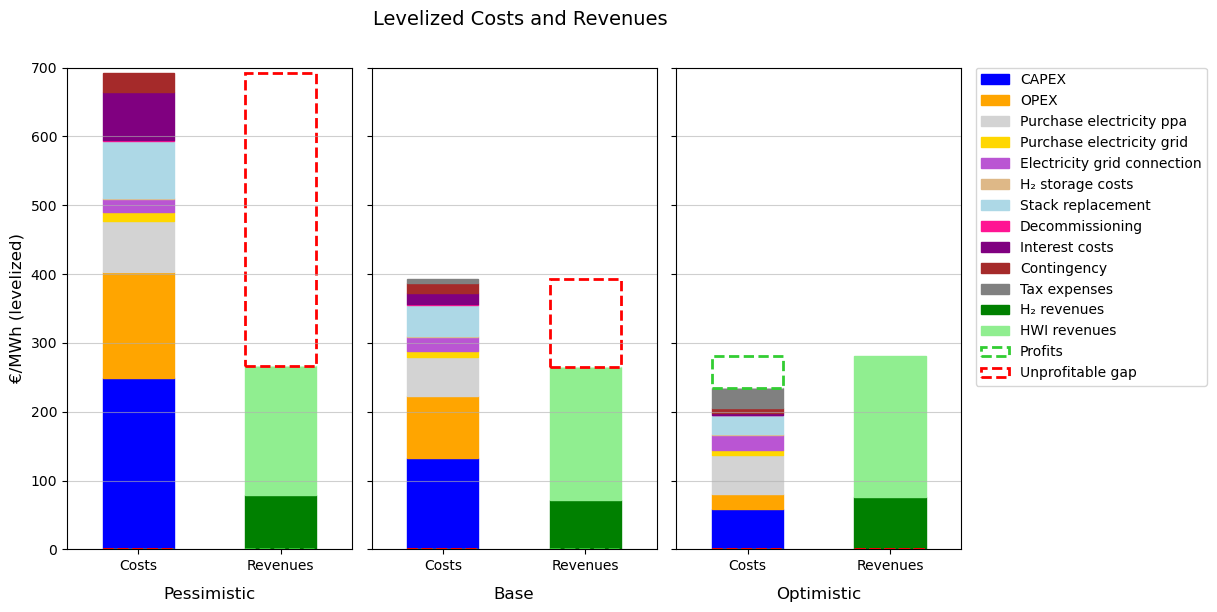

In [11]:
import ipynb.fs.defs.EL_working_file as el_module
import NSE6_EL_input_data as el_inputs

# 1. Generate the comparison data matrix
df_analysis = run_levelized_breakdown_scenarios(el_module, el_inputs)

# 2. Generate the figure
plot_scenario_breakdown(df_analysis, unit_label='€/MWh (levelized)')
